# LLM Adversary Evaluation

Tests the **AdaptiveAgent** against an out-of-distribution adversary: a GPT LLM playing Liar's Dice
with the same partial information any other agent receives (own dice + public state).

The LLM accumulates a compact summary of all previous rounds **within the same game**, giving it
within-game memory while staying comparable to the AdaptiveAgent.

**Sections:**
1. Setup & imports
2. Game loop helpers
3. Agent initialisation
4. Test game — one full match, verbose
5. Aggregated run — 50 games
6. Results & belief tracker analysis
7. Baseline comparison

## 1. Setup & Imports

In [1]:
import sys
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Notebook lives in scripts/ — repo root is one level up
REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))
print(f"Repo root: {REPO_ROOT}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
print("Libraries imported.")

Repo root: C:\Users\shaha\Work\Personal\AIGT\Adaptive-Strategy-Learning-in-Liar-s-Dice
Libraries imported.


In [8]:
# ── OpenAI config ──────────────────────────────────────────────────────────────
# Reads from env var if set; otherwise prompts at runtime.
# The entered value is captured into a variable and never echoed or saved in cell output.
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY") or input("OpenAI API key: ")
LLM_MODEL      = "gpt-4o-mini"   # supports gpt-4o*, gpt-4.1*, o1-o4, gpt-5+
LLM_TEMP       = 0.7             # only applied for gpt-4o* / gpt-4.1*; ignored otherwise

# ── Experiment config ──────────────────────────────────────────────────────────
NUM_GAMES   = 50
TOTAL_DICE  = 5
RANDOM_SEED = 42

try:
    from openai import OpenAI
    _oai_client = OpenAI(api_key=OPENAI_API_KEY)
    print(f"OpenAI client ready — model: {LLM_MODEL}")
except ImportError:
    print("openai package not found. Run: pip install openai")
    _oai_client = None

OpenAI client ready — model: gpt-4o-mini


In [3]:
from liars_dice.core.config    import GameConfig
from liars_dice.core.engine    import GameEngine
from liars_dice.agents.adaptive_agent import AdaptiveAgent
from liars_dice.agents.bayesian_agent import BayesianAgent
from liars_dice.agents.llm_agent      import LLMAdversaryAgent

# rng_seed=None seeds from the system clock, so each GameEngine gets
# independently rolled dice. A fixed seed makes every game a replay of the same rolls.
GAME_CONFIG = GameConfig(
    num_players=2,
    total_dice=TOTAL_DICE,
    faces=(1, 2, 3, 4, 5, 6),
    ones_wild=False,
    rng_seed=None,
)
print("Game config:", GAME_CONFIG)

Game config: GameConfig(num_players=2, total_dice=5, dice_distribution=None, faces=(1, 2, 3, 4, 5, 6), ones_wild=False, bid_ordering='quantity_then_face', allow_opening_bid_constraints=False, max_turns=64, rng_seed=None)


## 2. Game Loop Helpers

In [ ]:
from liars_dice.agents.llm_agent import LLMResponseError


def play_single_round(engine: GameEngine, agents: list) -> dict:
    """
    Purpose: Run one complete round of Liar's Dice to termination.
    Method: Alternate turns, call choose_action, apply_action; collect events.
            If an agent raises LLMResponseError (illegal / unparseable action)
            the offending player forfeits the round immediately.

    Args:
        engine (GameEngine): Initialised engine with start_new_round() already called.
        agents (list): [agent_for_player_0, agent_for_player_1].

    Returns:
        dict: {winner, loser, num_turns, was_true, bid_history}.
    """
    all_events = []
    num_turns  = 0

    while not engine.is_terminal():
        current = engine.state.public.current_player
        view    = engine.get_view(current)
        try:
            action = agents[current].choose_action(view)
        except LLMResponseError as e:
            # Illegal / unparseable LLM action — that player forfeits the round
            return {
                "winner":      1 - current,
                "loser":       current,
                "num_turns":   num_turns,
                "was_true":    False,
                "bid_history": list(engine.state.public.bid_history),
            }
        engine.apply_action(current, action)
        all_events.extend(engine.pop_events())
        num_turns += 1

    was_true = next(
        (e["was_true"] for e in all_events if e["type"] == "RoundEnded"), None
    )

    return {
        "winner":      engine.state.public.winner,
        "loser":       engine.state.public.loser,
        "num_turns":   num_turns,
        "was_true":    was_true,
        "bid_history": list(engine.state.public.bid_history),
    }


def play_match(adaptive: AdaptiveAgent, llm: LLMAdversaryAgent,
               config: GameConfig, adaptive_is_p0: bool) -> dict:
    """
    Purpose: Run one full match (dice-elimination) between AdaptiveAgent and LLM.
    Method: Multi-round loop; loser drops a die each round until someone hits 0.
            Calls llm.record_round() after each round to update within-game memory.

    Args:
        adaptive (AdaptiveAgent): Our trained adaptive agent.
        llm (LLMAdversaryAgent): The LLM adversary.
        config (GameConfig): Game configuration.
        adaptive_is_p0 (bool): Whether AdaptiveAgent plays as player 0.

    Returns:
        dict: {adaptive_won, rounds_played, belief_history, final_belief}.
    """
    adaptive.reset()
    llm.reset()

    agents         = [adaptive, llm] if adaptive_is_p0 else [llm, adaptive]
    llm_pid        = 1 if adaptive_is_p0 else 0
    adaptive_pid   = 1 - llm_pid
    engine         = GameEngine(config)
    dice_counts    = list(config.dice_distribution or (config.total_dice, config.total_dice))
    belief_history = []
    rounds_played  = 0

    while True:
        for i in range(2):
            engine.state.players[i].num_dice = dice_counts[i]

        llm_dice_before = dice_counts[llm_pid]
        opp_dice_before = dice_counts[adaptive_pid]

        engine.start_new_round()
        engine.pop_events()

        round_result = play_single_round(engine, agents)
        rounds_played += 1
        belief_history.append(adaptive.get_belief_summary())

        llm.record_round(
            bid_history = round_result["bid_history"],
            my_dice     = llm_dice_before,
            opp_dice    = opp_dice_before,
            i_won       = round_result["winner"] == llm_pid,
            was_true    = round_result["was_true"],
        )

        loser = round_result["loser"]
        if loser is not None:
            dice_counts[loser] -= 1

        if dice_counts[0] <= 0 or dice_counts[1] <= 0:
            winner_pid = 0 if dice_counts[0] > 0 else 1
            return {
                "adaptive_won":   winner_pid == adaptive_pid,
                "rounds_played":  rounds_played,
                "belief_history": belief_history,
                "final_belief":   belief_history[-1],
            }


print("Game loop helpers defined.")

## 3. Agent Initialisation

In [5]:
adaptive_agent = AdaptiveAgent(device="cpu")
llm_agent      = LLMAdversaryAgent(
    client      = _oai_client,
    model       = LLM_MODEL,
    temperature = LLM_TEMP,
    verbose     = False,   # set True to print every LLM prompt/response
)

print(f"AdaptiveAgent loaded.")
print(f"LLMAdversaryAgent — model: {LLM_MODEL}")

AdaptiveAgent loaded.
LLMAdversaryAgent — model: gpt-4o-mini


## 4. Test Game — One Full Match (Verbose)

Run a single match to verify the pipeline and inspect round-by-round behaviour.

In [6]:
adaptive_agent.reset()
llm_agent.reset()

ADAPTIVE_IS_P0 = True
agents       = [adaptive_agent, llm_agent] if ADAPTIVE_IS_P0 else [llm_agent, adaptive_agent]
adaptive_pid = 0 if ADAPTIVE_IS_P0 else 1
llm_pid      = 1 - adaptive_pid

engine    = GameEngine(GAME_CONFIG)
dice      = [TOTAL_DICE, TOTAL_DICE]
round_num = 0
SEP       = "═" * 54

print(f"AdaptiveAgent (P{adaptive_pid})  vs  LLM [{LLM_MODEL}] (P{llm_pid})")
print(SEP)

while min(dice) > 0:
    round_num += 1
    for i in range(2):
        engine.state.players[i].num_dice = dice[i]

    llm_dice_before = dice[llm_pid]
    opp_dice_before = dice[adaptive_pid]

    engine.start_new_round()
    engine.pop_events()

    result = play_single_round(engine, agents)

    bids_str   = "  →  ".join(f"{b.quantity}×{b.face}" for b in result["bid_history"]) or "(none)"
    outcome    = "TRUE bid  → caller lost" if result["was_true"] else "FALSE bid → bidder lost"
    loser_name = "AdaptiveAgent" if result["loser"] == adaptive_pid else "LLM"
    belief     = adaptive_agent.get_belief_summary()
    top_label  = max(belief["beliefs"], key=belief["beliefs"].get) if belief["beliefs"] else "—"
    top_conf   = belief["beliefs"].get(top_label, 0.0) if belief["beliefs"] else 0.0
    gen_flag   = "  [generalist]" if belief["using_generalist"] else ""

    print(f"\nRound {round_num:>2}  │  AdaptiveAgent: {dice[adaptive_pid]} dice  │  LLM: {dice[llm_pid]} dice")
    print(f"  Bids   : {bids_str}")
    print(f"  Outcome: LIAR called → {outcome}")
    print(f"  Result : {loser_name} loses a die")
    print(f"  Belief : {top_label} ({top_conf:.2f}){gen_flag}")

    llm_agent.record_round(
        bid_history = result["bid_history"],
        my_dice     = llm_dice_before,
        opp_dice    = opp_dice_before,
        i_won       = result["winner"] == llm_pid,
        was_true    = result["was_true"],
    )

    if result["loser"] is not None:
        dice[result["loser"]] -= 1

print(f"\n{SEP}")
winner_name = "AdaptiveAgent" if dice[adaptive_pid] > 0 else f"LLM [{LLM_MODEL}]"
print(f"GAME OVER — {winner_name} wins!  ({round_num} rounds played)")

AdaptiveAgent (P0)  vs  LLM [gpt-4o-mini] (P1)
══════════════════════════════════════════════════════

Round  1  │  AdaptiveAgent: 5 dice  │  LLM: 5 dice
  Bids   : 5×5  →  6×5
  Outcome: LIAR called → FALSE bid → bidder lost
  Result : LLM loses a die
  Belief : BayesianAgent (0.04)  [generalist]

Round  2  │  AdaptiveAgent: 5 dice  │  LLM: 4 dice
  Bids   : 5×6  →  6×6
  Outcome: LIAR called → FALSE bid → bidder lost
  Result : LLM loses a die
  Belief : BayesianAgent (0.04)  [generalist]

Round  3  │  AdaptiveAgent: 5 dice  │  LLM: 3 dice
  Bids   : 4×1  →  5×1
  Outcome: LIAR called → FALSE bid → bidder lost
  Result : LLM loses a die
  Belief : BayesianAgent (0.04)  [generalist]

Round  4  │  AdaptiveAgent: 5 dice  │  LLM: 2 dice
  Bids   : 1×1  →  2×1  →  4×1  →  5×1
  Outcome: LIAR called → FALSE bid → bidder lost
  Result : LLM loses a die
  Belief : BayesianAgent (0.04)  [generalist]

Round  5  │  AdaptiveAgent: 5 dice  │  LLM: 1 dice
  Bids   : 5×6
  Outcome: LIAR called → FA

## 5. Aggregated Run — 50 Games

In [ ]:
results = []
wins    = 0

pbar = tqdm(range(NUM_GAMES), desc="Games", unit="game")
for game_idx in pbar:
    adaptive_is_p0 = (game_idx % 2 == 0)   # alternate first-mover

    result       = play_match(adaptive_agent, llm_agent, GAME_CONFIG,
                              adaptive_is_p0=adaptive_is_p0)
    final_belief = result["final_belief"]
    top_label    = (
        max(final_belief["beliefs"], key=final_belief["beliefs"].get)
        if final_belief["beliefs"] else "generalist"
    )

    if result["adaptive_won"]:
        wins += 1

    results.append({
        "game":              game_idx,
        "adaptive_is_p0":   adaptive_is_p0,
        "adaptive_won":     result["adaptive_won"],
        "rounds_played":    result["rounds_played"],
        "using_generalist": final_belief["using_generalist"],
        "top_label":        top_label,
        "top_belief":       final_belief["beliefs"].get(top_label, 0.0),
    })

    played = game_idx + 1
    pbar.set_postfix(
        adaptive_wins=f"{wins}/{played}",
        win_rate=f"{wins/played:.0%}",
        rounds=str(result["rounds_played"]),
    )

df = pd.DataFrame(results)
print(f"Done — AdaptiveAgent won {wins}/{NUM_GAMES} games ({wins/NUM_GAMES:.1%})")

## 6. Results & Belief Analysis

In [ ]:
n_wins  = df["adaptive_won"].sum()
n_total = len(df)
wr      = n_wins / n_total

# Wilson 95% confidence interval
from scipy.stats import norm as _norm
z  = _norm.ppf(0.975)
lo = (wr + z**2/(2*n_total) - z*np.sqrt(wr*(1-wr)/n_total + z**2/(4*n_total**2))) / (1 + z**2/n_total)
hi = (wr + z**2/(2*n_total) + z*np.sqrt(wr*(1-wr)/n_total + z**2/(4*n_total**2))) / (1 + z**2/n_total)

print("=" * 50)
print(f"AdaptiveAgent vs {LLM_MODEL}")
print(f"  Games:    {n_total}")
print(f"  Win rate: {wr:.1%}  (95% CI: [{lo:.1%}, {hi:.1%}])")
print("=" * 50)

for pos, label in [(True, "as P0"), (False, "as P1")]:
    sub = df[df["adaptive_is_p0"] == pos]
    print(f"  Win rate {label}: {sub['adaptive_won'].mean():.1%}  (n={len(sub)})")

print(f"\nRounds per match — mean: {df['rounds_played'].mean():.1f}  "
      f"median: {df['rounds_played'].median():.0f}  "
      f"max: {df['rounds_played'].max()}")

label_counts   = df["top_label"].value_counts()
generalist_pct = df["using_generalist"].mean()
print(f"\nBelief tracker — top labels assigned to LLM:")
print(label_counts.to_string())
print(f"\nGeneralist fallback: {generalist_pct:.1%}  "
      f"| Mean top-belief confidence: {df['top_belief'].mean():.3f}")

AdaptiveAgent vs gpt-4o-mini
  Games:    20
  Win rate: 20.0%  (95% CI: [8.1%, 41.6%])
  Win rate as P0: 40.0%  (n=10)
  Win rate as P1: 0.0%  (n=10)

Rounds per match — mean: 7.8  median: 8  max: 9

Belief tracker — top labels assigned to LLM:
top_label
BayesianAgent    20

Generalist fallback: 100.0%  | Mean top-belief confidence: 0.042


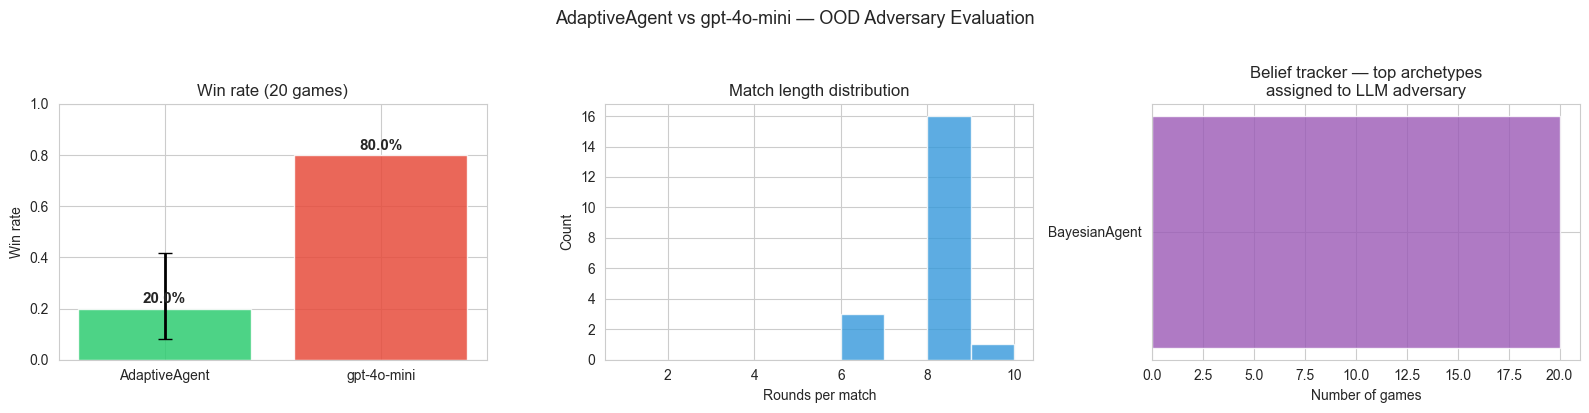

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax   = axes[0]
bars = ax.bar(["AdaptiveAgent", LLM_MODEL], [wr, 1 - wr],
              color=["#2ecc71", "#e74c3c"], alpha=0.85)
ax.errorbar([0], [wr], yerr=[[wr - lo], [hi - wr]], fmt="none",
            color="black", capsize=5, linewidth=2)
ax.set_ylim(0, 1)
ax.set_ylabel("Win rate")
ax.set_title(f"Win rate ({n_total} games)")
for bar, val in zip(bars, [wr, 1 - wr]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")

ax = axes[1]
ax.hist(df["rounds_played"], bins=range(1, df["rounds_played"].max() + 2),
        color="#3498db", alpha=0.8, edgecolor="white")
ax.set_xlabel("Rounds per match")
ax.set_ylabel("Count")
ax.set_title("Match length distribution")

ax    = axes[2]
top_n = label_counts.head(8)
ax.barh(top_n.index[::-1], top_n.values[::-1], color="#9b59b6", alpha=0.8)
ax.set_xlabel("Number of games")
ax.set_title("Belief tracker — top archetypes\nassigned to LLM adversary")

plt.suptitle(f"AdaptiveAgent vs {LLM_MODEL} — OOD Adversary Evaluation",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()